In [8]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller

In [9]:
sales_of_company_x = pd.read_csv("../data/Series/monthly-sales-of-company-x-jan-6.csv")
robberies_in_boston = pd.read_csv("../data/Series/monthly-boston-armed-robberies-j.csv")
airlines_passengers = pd.read_csv("../data/Series/international-airline-passengers.csv")
mean_monthly_temp = pd.read_csv("../data/Series/mean-monthly-air-temperature-deg.csv")
dowjones_closing = pd.read_csv("../data/Series/weekly-closings-of-the-dowjones-.csv")
female_births = pd.read_csv("../data/Series/daily-total-female-births-in-cal.csv")

In [10]:
all_series = {
    "Monthly sales of company X": sales_of_company_x["Count"],
    "Monthly Boston armed robberies": robberies_in_boston["Count"],
    "International airline passengers: monthly totals in thousands": airlines_passengers["Count"],
    "Mean monthly air temperature (Deg. F) Nottingham Castle": mean_monthly_temp["Deg"],
    "Weekly closings of the Dow-Jones industrial average": dowjones_closing["Close"],
    "Daily total female births in California": female_births["Count"]
}

In [11]:
def adf_test(series, title=''):
    result = adfuller(series.dropna())
    pvalue = result[1]
    print(f'ADF test {title}: p-value = {pvalue:.4f}')
    return pvalue


def rolling_ma(series, window):
    return series.rolling(window=window, min_periods=1).mean()


def ema(series, span):
    return series.ewm(span=span, adjust=False).mean()


def dema(series, span):
    e1 = series.ewm(span=span, adjust=False).mean()
    e2 = e1.ewm(span=span, adjust=False).mean()
    return 2 * e1 - e2


def tema(series, span):
    e1 = series.ewm(span=span, adjust=False).mean()
    e2 = e1.ewm(span=span, adjust=False).mean()
    e3 = e2.ewm(span=span, adjust=False).mean()
    return 3 * e1 - 3 * e2 + e3


def one_step_predict_from_smoother(smoother_series):
    return float(smoother_series.iloc[-1])


def evaluate_preds(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse}


# walk-forward валидация для подбора параметра на первых наблюдениях ряда
def tune_param_and_forecast(orig_series, smoother_name, param_grid, tune_len=12):
    s = orig_series.dropna().reset_index(drop=True)
    # последний шаг -- holdout (прогноз на последний элемент)
    train_full = s[:-1].copy().reset_index(drop=True)
    # используем только первые tune_len наблюдений для подбора параметров
    k = int(tune_len) if tune_len is not None else len(train_full)
    k = max(2, min(k, len(train_full)))

    best_param = None
    best_mae = np.inf
    results = {}
    # для каждого параметра делаем walk-forward на первых k точках:
    # на шаге i (i от 1 до k-1) используем s[:i] для прогноза s[i]
    for p in param_grid:
        preds, trues = [], []
        for i in range(1, k):
            data_up_to = train_full[:i]
            if len(data_up_to) == 0:
                continue
            if smoother_name == 'MA':
                smooth = rolling_ma(data_up_to, window=p)
            elif smoother_name == 'EMA':
                smooth = ema(data_up_to, span=p)
            elif smoother_name == 'DEMA':
                smooth = dema(data_up_to, span=p)
            elif smoother_name == 'TEMA':
                smooth = tema(data_up_to, span=p)
            else:
                raise ValueError('Unknown smoother')
            pred = one_step_predict_from_smoother(smooth)
            preds.append(pred)
            trues.append(float(train_full.iloc[i]))
        mae = mean_absolute_error(trues, preds) if len(preds) > 0 else np.inf
        results[p] = mae
        if mae < best_mae:
            best_mae = mae
            best_param = p

    # после подбора параметра, обучаем на train_full и прогнозируем последний элемент s[-1]
    if smoother_name == 'MA':
        smooth_full = rolling_ma(train_full, window=best_param)
    elif smoother_name == 'EMA':
        smooth_full = ema(train_full, span=best_param)
    elif smoother_name == 'DEMA':
        smooth_full = dema(train_full, span=best_param)
    elif smoother_name == 'TEMA':
        smooth_full = tema(train_full, span=best_param)
    forecast_last = one_step_predict_from_smoother(smooth_full)
    return {'best_param': best_param, 'val_mae': best_mae, 'forecast_last': forecast_last, 'grid': results}


def run_experiment_on_series(series, series_name, param_range=range(2, 13), tune_len=12):
    print('---', series_name, 'len=', len(series))
    pvalue = adf_test(series, title=series_name)
    stationarity = 'stationary' if pvalue < 0.05 else 'non-stationary'
    print('Определение ряда:', stationarity)
    s = series.dropna().reset_index(drop=True)
    if len(s) < 6:
        raise ValueError('Ряд слишком короткий для эксперимента')
    results = {}
    models = ['MA', 'EMA', 'DEMA', 'TEMA']
    for m in models:
        res = tune_param_and_forecast(s, m, param_range, tune_len=tune_len)
        # метрики: сравним прогноз на последний с реальным последним значением
        y_true = float(s.iloc[-1])
        y_pred = float(res['forecast_last'])
        metrics = evaluate_preds([y_true], [y_pred])
        results[m] = {'best_param': res['best_param'],
                      'val_mae': res['val_mae'],
                      'forecast_last': y_pred,
                      'true_last': y_true,
                      **metrics}
        print(
            f'{m}: best_param={res["best_param"]}, val_mae={res["val_mae"]:.4f}, forecast_last={y_pred:.4f}, true_last={y_true:.4f}')
    # табличный вывод
    df_res = pd.DataFrame(results).T
    df_res = df_res[['best_param', 'val_mae', 'forecast_last', 'true_last', 'MAE', 'MSE', 'RMSE']]
    return {'adf_pvalue': pvalue, 'stationarity': stationarity, 'table': df_res, 'series': s}

In [12]:
adf_pvals = {name: adf_test(ser, title=name) for name, ser in all_series.items()}

# сортируем по p-value: p < 0.05 => стационарный (вероятно), >=0.05 => нестационарный
stationary_candidates = [name for name, p in adf_pvals.items() if p < 0.05]
nonstationary_candidates = [name for name, p in adf_pvals.items() if p >= 0.05]

print('\nСтационарные кандидаты:', stationary_candidates)
print('Нестационарные кандидаты:', nonstationary_candidates)

# выбираем первый из каждого списка (если нет, берем ближайший)
if len(stationary_candidates) > 0:
    stationary_name = stationary_candidates[0]
else:
    stationary_name = list(all_series.keys())[0]

if len(nonstationary_candidates) > 0:
    nonstationary_name = nonstationary_candidates[0]
else:
    nonstationary_name = list(all_series.keys())[1]

print('\nВыбран стационарный ряд:', stationary_name)
print('Выбран нестационарный ряд:', nonstationary_name)

# запуск
res_stationary = run_experiment_on_series(all_series[stationary_name], stationary_name, param_range=range(2, 13),
                                          tune_len=12)

res_nonstationary = run_experiment_on_series(all_series[nonstationary_name], nonstationary_name,
                                             param_range=range(2, 13), tune_len=12)

# таблицы результатов
print('\nРезультаты для стационарного ряда:', stationary_name)
display(res_stationary['table'])

print('\nРезультаты для нестационарного ряда:', nonstationary_name)
display(res_nonstationary['table'])

ADF test Monthly sales of company X: p-value = 0.9889
ADF test Monthly Boston armed robberies: p-value = 0.9943
ADF test International airline passengers: monthly totals in thousands: p-value = 0.9919
ADF test Mean monthly air temperature (Deg. F) Nottingham Castle: p-value = 0.0170
ADF test Weekly closings of the Dow-Jones industrial average: p-value = 0.6225
ADF test Daily total female births in California: p-value = 0.0001

Стационарные кандидаты: ['Mean monthly air temperature (Deg. F) Nottingham Castle', 'Daily total female births in California']
Нестационарные кандидаты: ['Monthly sales of company X', 'Monthly Boston armed robberies', 'International airline passengers: monthly totals in thousands', 'Weekly closings of the Dow-Jones industrial average']

Выбран стационарный ряд: Mean monthly air temperature (Deg. F) Nottingham Castle
Выбран нестационарный ряд: Monthly sales of company X
--- Mean monthly air temperature (Deg. F) Nottingham Castle len= 240
ADF test Mean monthly air 

,best_param,val_mae,forecast_last,true_last,MAE,MSE,RMSE
MA,2.0,4.704545,46.650000,37.8,8.850000,78.322500,8.850000
EMA,2.0,4.346300,48.009062,37.8,10.209062,104.224941,10.209062
DEMA,2.0,3.642506,46.135128,37.8,8.335128,69.474356,8.335128
TEMA,2.0,3.393010,46.088325,37.8,8.288325,68.696324,8.288325



Результаты для нестационарного ряда: Monthly sales of company X


,best_param,val_mae,forecast_last,true_last,MAE,MSE,RMSE
MA,2.0,53.636364,286.000000,272.0,14.000000,196.000000,14.000000
EMA,2.0,50.476421,284.622021,272.0,12.622021,159.315406,12.622021
DEMA,2.0,42.160907,242.889686,272.0,29.110314,847.410410,29.110314
TEMA,2.0,39.687096,247.683704,272.0,24.316296,591.282262,24.316296


--- Mean monthly air temperature (Deg. F) Nottingham Castle ---
ADF test Mean monthly air temperature (Deg. F) Nottingham Castle: p-value = 0.0170
MA: best_p=2, RMSE=6.6889
EMA: best_p=2, RMSE=6.3331
DEMA: best_p=2, RMSE=5.4817
TEMA: best_p=2, RMSE=5.1665


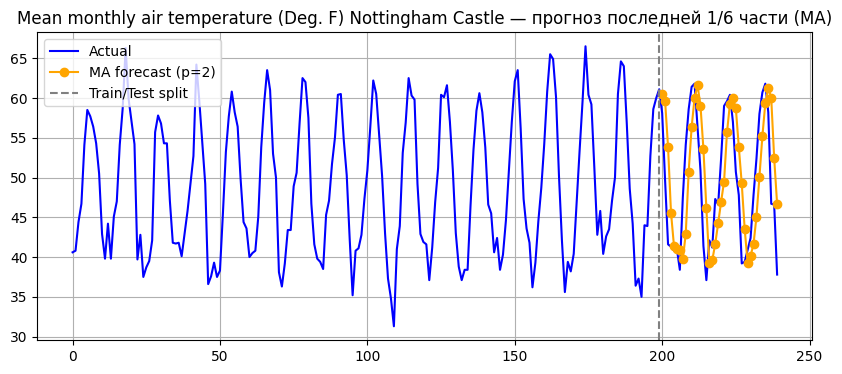

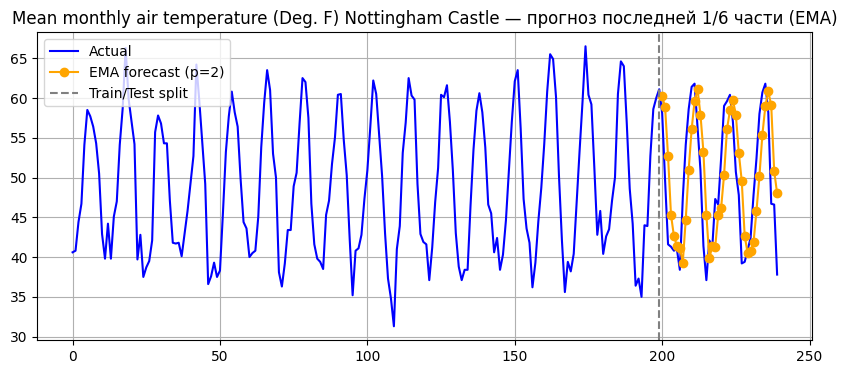

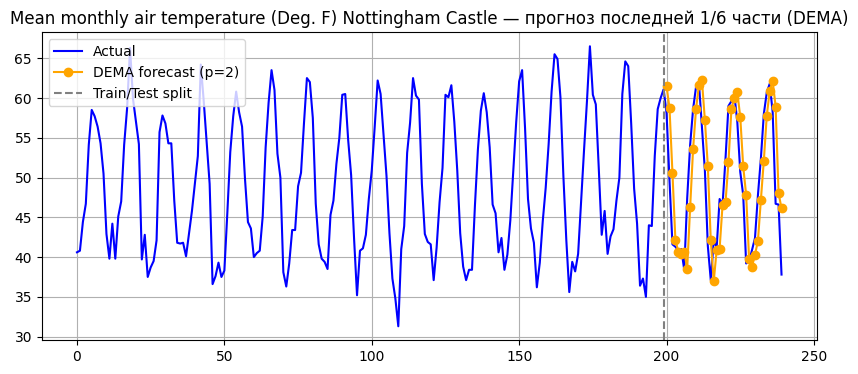

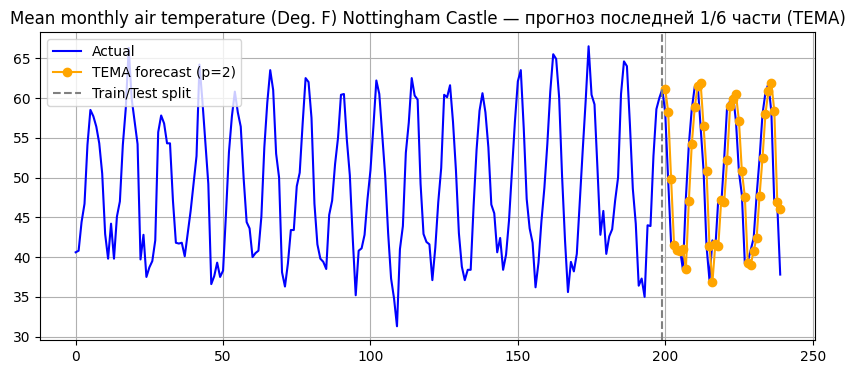

--- Monthly sales of company X ---
ADF test Monthly sales of company X: p-value = 0.9889
MA: best_p=2, RMSE=192.7921
EMA: best_p=2, RMSE=182.8639
DEMA: best_p=2, RMSE=162.4836
TEMA: best_p=2, RMSE=154.5302


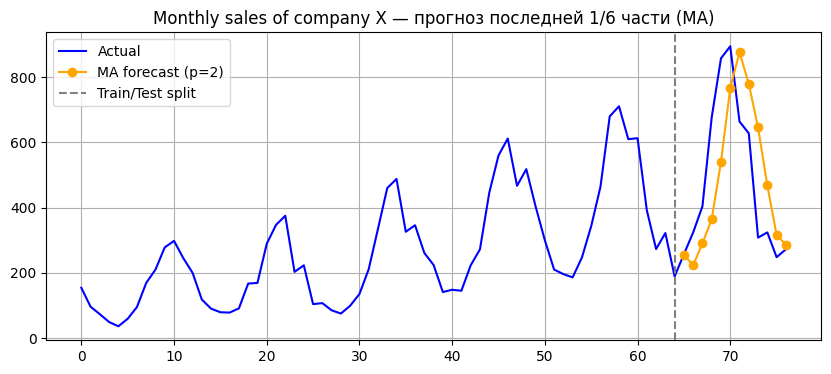

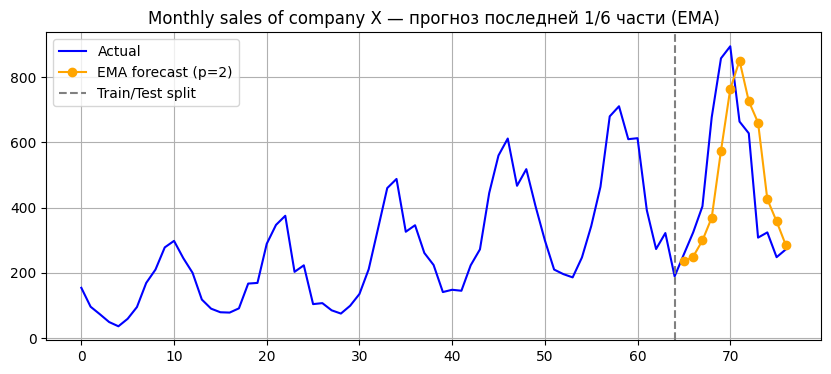

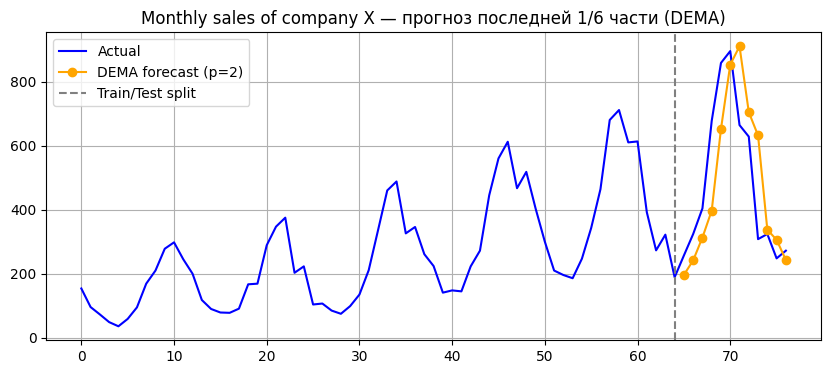

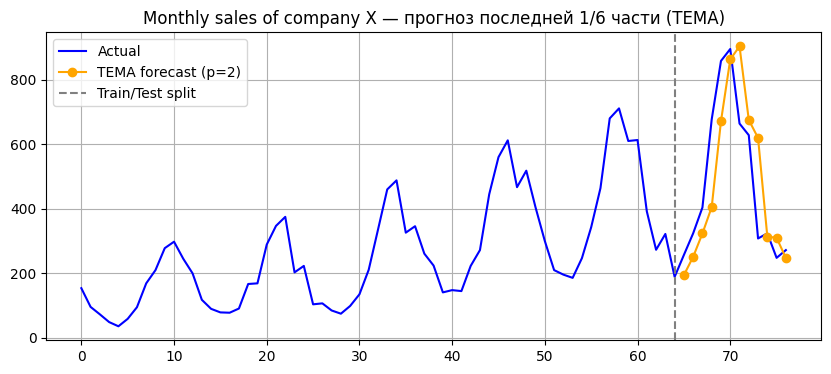

In [13]:
def forecast_last_fraction(series, model_name, param_grid, fraction=6):
    """Прогнозируем последнюю 1/fraction часть ряда с помощью walk-forward."""
    s = series.dropna().reset_index(drop=True)
    n = len(s)
    split_idx = n - n // fraction
    train, test = s[:split_idx], s[split_idx:]

    # подбираем лучший параметр на тренировке
    res = tune_param_and_forecast(train, model_name, param_grid)
    best_p = res['best_param']

    preds = []
    history = train.copy()
    for i in range(len(test)):
        if model_name == 'MA':
            smooth = rolling_ma(history, window=best_p)
        elif model_name == 'EMA':
            smooth = ema(history, span=best_p)
        elif model_name == 'DEMA':
            smooth = dema(history, span=best_p)
        elif model_name == 'TEMA':
            smooth = tema(history, span=best_p)
        pred = one_step_predict_from_smoother(smooth)
        preds.append(pred)
        # добавляем реальное значение (walk-forward)
        history = pd.concat([history, pd.Series([test.iloc[i]])], ignore_index=True)

    metrics = evaluate_preds(test.values, preds)
    return {'best_param': best_p, 'y_true': test.values, 'y_pred': preds, **metrics}


def run_experiment_last_fraction(series, series_name, param_range=range(2, 13), fraction=6):
    print(f'--- {series_name} ---')
    pvalue = adf_test(series, title=series_name)
    stationarity = 'stationary' if pvalue < 0.05 else 'non-stationary'
    results = {}
    for model in ['MA', 'EMA', 'DEMA', 'TEMA']:
        res = forecast_last_fraction(series, model, param_range, fraction)
        results[model] = res
        print(f'{model}: best_p={res["best_param"]}, RMSE={res["RMSE"]:.4f}')
    return {'stationarity': stationarity, 'results': results}


def plot_last_fraction_separate(series, exp_res, series_name, fraction=6):
    s = series.dropna().reset_index(drop=True)
    n = len(s)
    split_idx = n - n // fraction
    train_index = range(split_idx)
    test_index = range(split_idx, n)

    for model, res in exp_res['results'].items():
        plt.figure(figsize=(10, 4))
        # реальные данные
        plt.plot(range(n), s.values, label='Actual', color='blue')
        # прогноз только на тесте
        plt.plot(test_index, res['y_pred'], marker='o', color='orange',
                 label=f'{model} forecast (p={res["best_param"]})')
        # граница train/test
        plt.axvline(split_idx - 1, color='gray', linestyle='--', label='Train/Test split')

        plt.title(f'{series_name} — прогноз последней 1/{fraction} части ({model})')
        plt.legend()
        plt.grid(True)
        plt.show()


# стационарный ряд
exp_stationary = run_experiment_last_fraction(all_series[stationary_name], stationary_name)
plot_last_fraction_separate(all_series[stationary_name], exp_stationary, stationary_name)

# нестационарный ряд
exp_nonstationary = run_experiment_last_fraction(all_series[nonstationary_name], nonstationary_name)
plot_last_fraction_separate(all_series[nonstationary_name], exp_nonstationary, nonstationary_name)

In [14]:
def choose_best(df):
    # выбираем модель с минимальным RMSE на прогнозе последнего шага (как основную метрику)
    best = df['RMSE'].idxmin()
    return best


best_stat = choose_best(res_stationary['table'])
best_nonstat = choose_best(res_nonstationary['table'])

print(f'Рекомендация: для стационарного ряда \"{stationary_name}\" лучшая модель: {best_stat}')
print(f'Рекомендация: для нестационарного ряда \"{nonstationary_name}\" лучшая модель: {best_nonstat}')

Рекомендация: для стационарного ряда "Mean monthly air temperature (Deg. F) Nottingham Castle" лучшая модель: TEMA
Рекомендация: для нестационарного ряда "Monthly sales of company X" лучшая модель: EMA
